# Objectif 

Extraction d'une portion d'intérêt

Date de création : 28/09/2026

In [1]:
import os
import sys
import numpy as np
import xarray as xr 
import pandas as pd
import soundfile as sf
import scipy.signal as sp
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates

from datetime import datetime, timedelta

project_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
sys.path.append(
    project_root
)  # \real_data_analysis\fiberscope_groix\src\data_processing
root_data = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\data"
)
root_bathy_data = os.path.join(project_root, "data", "bathy")
from publication.publication_figure import PubFigure, set_subfigures_abc_labels
PubFigure()

from real_data_analysis.acouplane.src.utils import *

# Chargement des données 

In [2]:
# Read wav dataset
ds_wav = xr.open_dataset(wav_dataset_fpath)
ds_wav

<xarray.Dataset> Size: 1GB
Dimensions:      (time4: 50021500, time7: 50021500, timea: 50012250,
                  timeb: 50000750, timec: 50014750, timed: 50004000, obs_id: 6)
Coordinates:
  * obs_id       (obs_id) int64 48B 4 7 1 2 5 6
Dimensions without coordinates: time4, time7, timea, timeb, timec, timed
Data variables:
    signal_obs4  (time4) float32 200MB ...
    signal_obs7  (time7) float32 200MB ...
    signal_obsa  (timea) float32 200MB ...
    signal_obsb  (timeb) float32 200MB ...
    signal_obsc  (timec) float32 200MB ...
    signal_obsd  (timed) float32 200MB ...
    rcv_name     (obs_id) <U4 96B ...
    fs           (obs_id) int64 48B ...
Attributes: (12/15)
    description:          Merged wav files from ACOUPLANE data sample.
    channel:              H
    start_datetime_obs4:  2026-02-24_19-56-47
    end_datetime_obs4:    2026-02-25_02-53-37
    start_datetime_obs7:  2026-02-24_16-26-45
    end_datetime_obs7:    2026-02-24_23-23-27
    ...                   ...
    end_datetime_obsb:    2026-02-24_23-26-40
    start_datetime_obsc:  2026-02-24_16-00-00
    end_datetime_obsc:    2026-02-24_22-56-47
    start_datetime_obsd:  2026-02-24_20-36-42
    end_datetime_obsd:    2026-02-25_03-33-24
    datetime_format:      %Y-%m-%d_%H-%M-%S

In [3]:
# Read source pos dataset
ds_src_pos = xr.open_dataset(source_position_dataset_fpath)
ds_src_pos

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 85601)
Coordinates:
  * time     (time) datetime64[ns] 685kB 2026-02-24 ... 2026-02-25
Data variables:
    lon      (time) float64 685kB ...
    lat      (time) float64 685kB ...

In [4]:
# Read OBS pos
df_obs_pos = pd.read_csv(
    obs_position_fpath,
    dtype={
        "obs_id": str,
        "lon": np.float64,
        "lat": np.float64,
    },
)
df_obs_pos

,obs_id,lon,lat
0,obs1,5.98821,43.03202
1,obs2,5.98822,43.03202
2,obs4,5.98822,43.03202
3,obs5,5.98821,43.03202
4,obs6,5.98820,43.03187
5,obs7,5.98950,43.03168


# Tracé des positions de la source pour identification d'une portion favorable 

Text(0, 0.5, 'Latitude [°]')

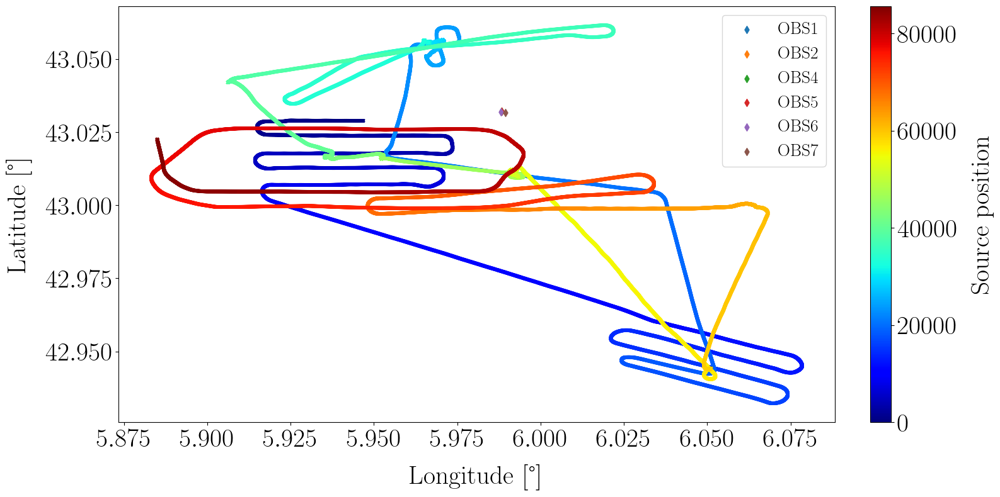

In [5]:
plt.figure()
for obs_id in df_obs_pos.obs_id:
    obs = df_obs_pos.loc[df_obs_pos["obs_id"] == obs_id]
    plt.scatter(obs.lon, obs.lat, marker="d", label=f"{obs.obs_id.values[0].upper()}")

sc = plt.scatter(
    ds_src_pos.lon,
    ds_src_pos.lat,
    cmap="jet",
    c=np.arange(ds_src_pos.time.size),
    marker="x",
    s=10,
)
plt.colorbar(sc, label="Source position")
plt.legend()
plt.xlabel("Longitude [°]")
plt.ylabel("Latitude [°]")

L'objectif est de reproduire un cadre similaire à celui de l'article de Verlinden et al. 2015 :  

* Une trajectoire *library* 
* Une ou plusieurs trajectoires *event*

In [6]:
# # OPTION 1 : croisement le plus proche (pour l'instant pas la donnée dispo)
# lib_traj = {
#     "start":21900,
#     "end":22500,
#     # "start": 35000,
#     # "end": 4500,
# }
# event_1_traj = {
#     "start": 2000,
#     "end": 2800,
# }
# event_2_traj = {
#     "start": 79300,
#     "end": 80200,
# }

# OPTION 2 : croisement un peu plus loin
lib_traj = {
    "start": 54000,
    "end": 55000,
}
event_1_traj = {
    "start": 69800,
    "end": 70800,
}
# event_1_traj = {
#     "start": 65000,
#     "end": 66000,
# }
event_2_traj = {
    "start": 72300,
    "end": 73300,
}

Text(0, 0.5, 'Latitude [°]')

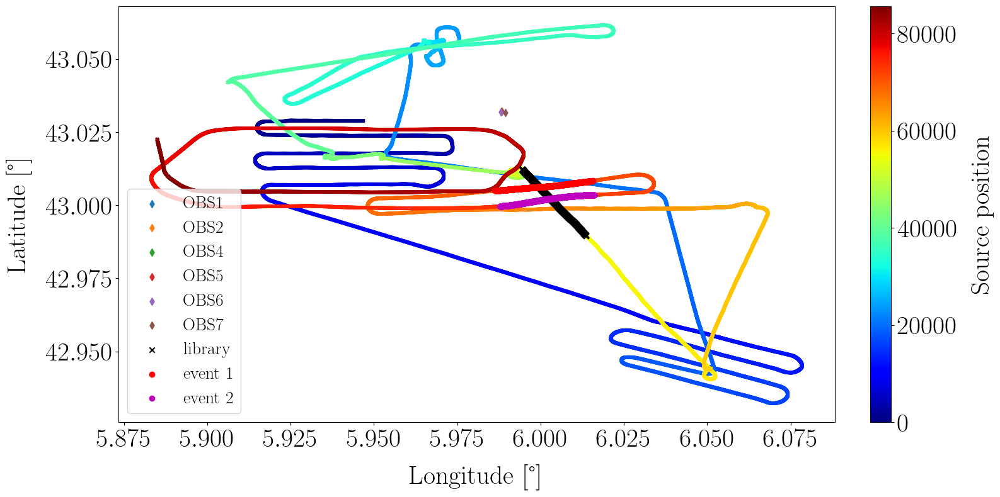

In [7]:
plt.figure()
for obs_id in df_obs_pos.obs_id:
    obs = df_obs_pos.loc[df_obs_pos["obs_id"] == obs_id]
    plt.scatter(obs.lon, obs.lat, marker="d", label=f"{obs.obs_id.values[0].upper()}")

sc = plt.scatter(
    ds_src_pos.lon,
    ds_src_pos.lat,
    cmap="jet",
    c=np.arange(ds_src_pos.time.size),
    marker="x",
    s=10,
)
# Library
lib_pos = ds_src_pos.isel(time=slice(lib_traj["start"], lib_traj["end"]))
plt.scatter(lib_pos.lon, lib_pos.lat, marker="x", color="k", label="library")
# Event
event_1_pos = ds_src_pos.isel(time=slice(event_1_traj["start"], event_1_traj["end"]))
plt.scatter(event_1_pos.lon, event_1_pos.lat, marker="o", color="r", label="event 1")
# Event 2
event_2_pos = ds_src_pos.isel(time=slice(event_2_traj["start"], event_2_traj["end"]))
plt.scatter(event_2_pos.lon, event_2_pos.lat, marker="o", color="m", label="event 2")
plt.colorbar(sc, label="Source position")
plt.legend()
plt.xlabel("Longitude [°]")
plt.ylabel("Latitude [°]")

Text(0, 0.5, 'Latitude [°]')

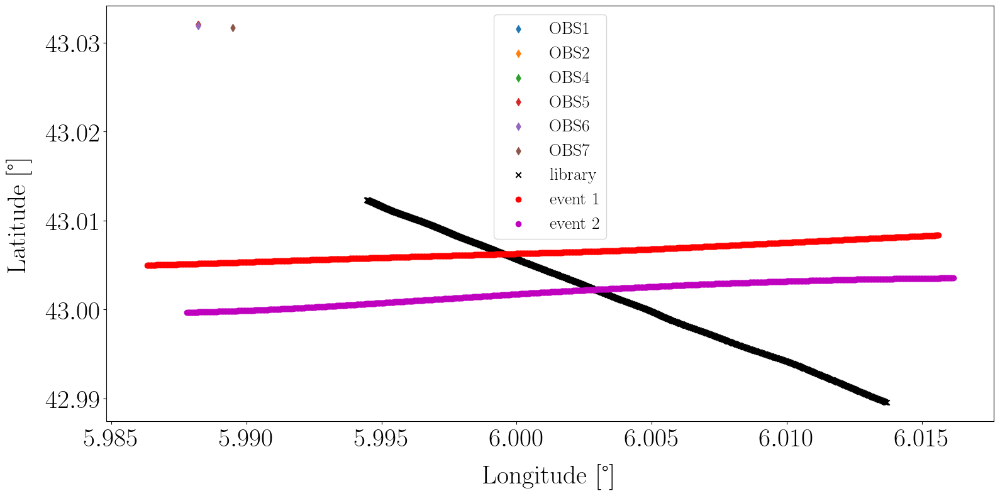

In [8]:
plt.figure()
for obs_id in df_obs_pos.obs_id:
    obs = df_obs_pos.loc[df_obs_pos["obs_id"] == obs_id]
    plt.scatter(obs.lon, obs.lat, marker="d", label=f"{obs.obs_id.values[0].upper()}")

plt.scatter(lib_pos.lon, lib_pos.lat, marker="x", color="k", label="library")
plt.scatter(event_1_pos.lon, event_1_pos.lat, marker="o", color="r", label="event 1")
plt.scatter(event_2_pos.lon, event_2_pos.lat, marker="o", color="m", label="event 2")
plt.legend()
plt.xlabel("Longitude [°]")
plt.ylabel("Latitude [°]")

# Représentation des signaux associés à chaque segment 

## Library 

In [9]:
start_dt = lib_pos.time.values[0]
end_dt = lib_pos.time.values[-1]
print(start_dt, end_dt)
# analysis_duration_s = 10 * 60

# plot_sequence(
#     ds_wav, start_analysis_dt, analysis_duration_s, nperseg=2**7, alpha_overlap=0.75
# )

2026-02-24T15:13:00.000003803 2026-02-24T15:29:40.999995764


## Event 1 

2026-02-24_19-36-33 2026-02-24_19-53-12


ValueError: x and y must have same first dimension, but have shapes (1200000,) and (0,)

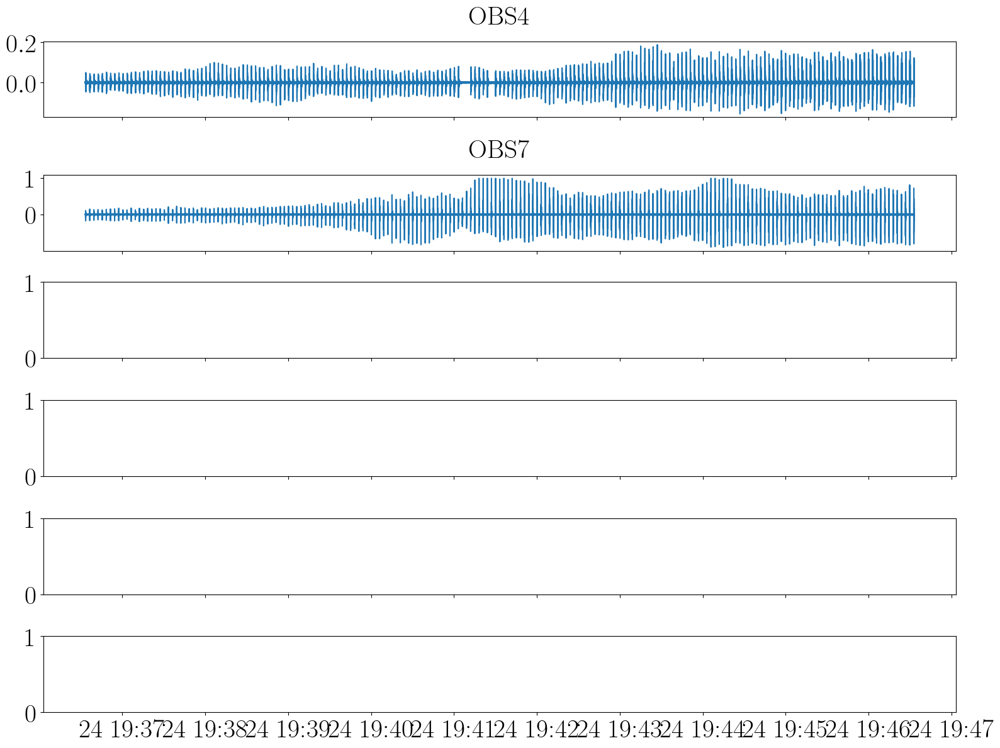

In [10]:
start_dt = event_1_pos.time.values[0]
start_dt = pd.to_datetime(str(start_dt)).strftime(datetime_format)
end_dt = event_1_pos.time.values[-1]
end_dt = pd.to_datetime(str(end_dt)).strftime(datetime_format)
print(start_dt, end_dt)
analysis_duration_s = 10 * 60

plot_sequence(ds_wav, start_dt, analysis_duration_s, nperseg=2**7, alpha_overlap=0.75)

## Event 2 

2026-02-24_20-18-14 2026-02-24_20-34-54


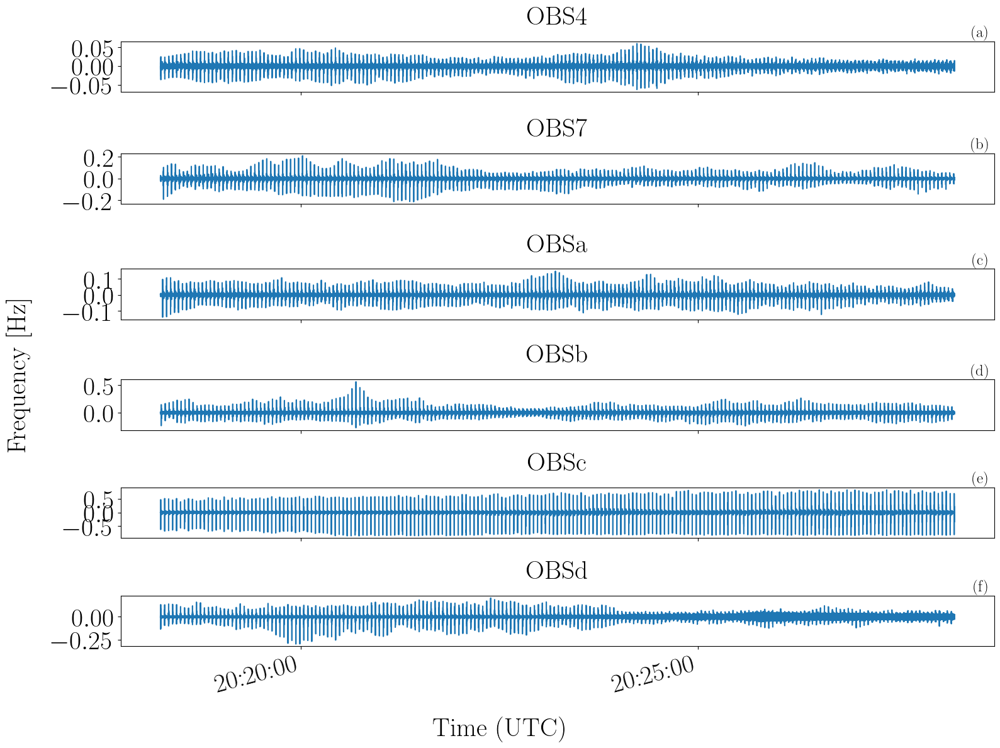

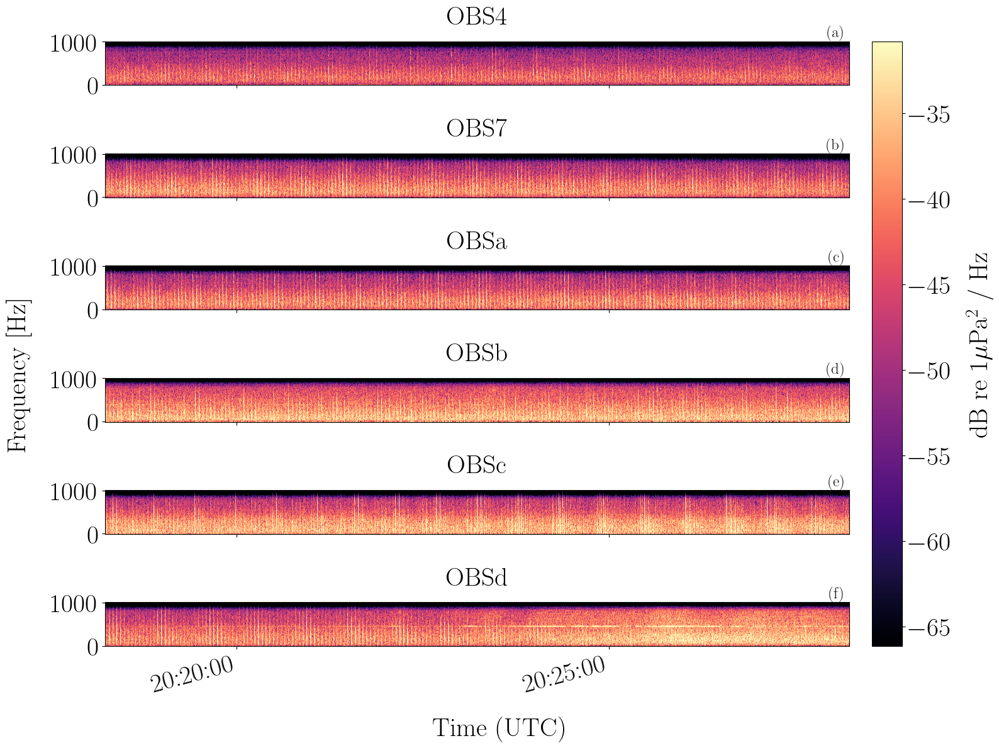

In [11]:
start_dt = event_2_pos.time.values[0]
start_dt = pd.to_datetime(str(start_dt)).strftime(datetime_format)
end_dt = event_2_pos.time.values[-1]
end_dt = pd.to_datetime(str(end_dt)).strftime(datetime_format)
print(start_dt, end_dt)
analysis_duration_s = 10 * 60

plot_sequence(ds_wav, start_dt, analysis_duration_s, nperseg=2**7, alpha_overlap=0.75)

## Détection des arrivées 

### STA / LTA 

In [12]:
# interval_inter_pulse_s = 3
# sta_duration = 0.45
# lta_duration = 3
# sta_lta_threshold_obs4 = 0.5
# sta_lta_threshold_obs7 = 0.65

# sig_dt, signals, arrivals_dt, arrivals_dt_idx = apply_sta_lta(
#     ds_wav,
#     sta_duration,
#     lta_duration,
#     start_analysis_dt,
#     analysis_duration_s,
#     sta_lta_threshold_obs4,
#     sta_lta_threshold_obs7,
# )

C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\src\utils.py:533: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\src\utils.py:533: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\src\utils.py:533: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\src\utils.py:533: UserWarning: No artists with labels found to put in legend.  Note that artis

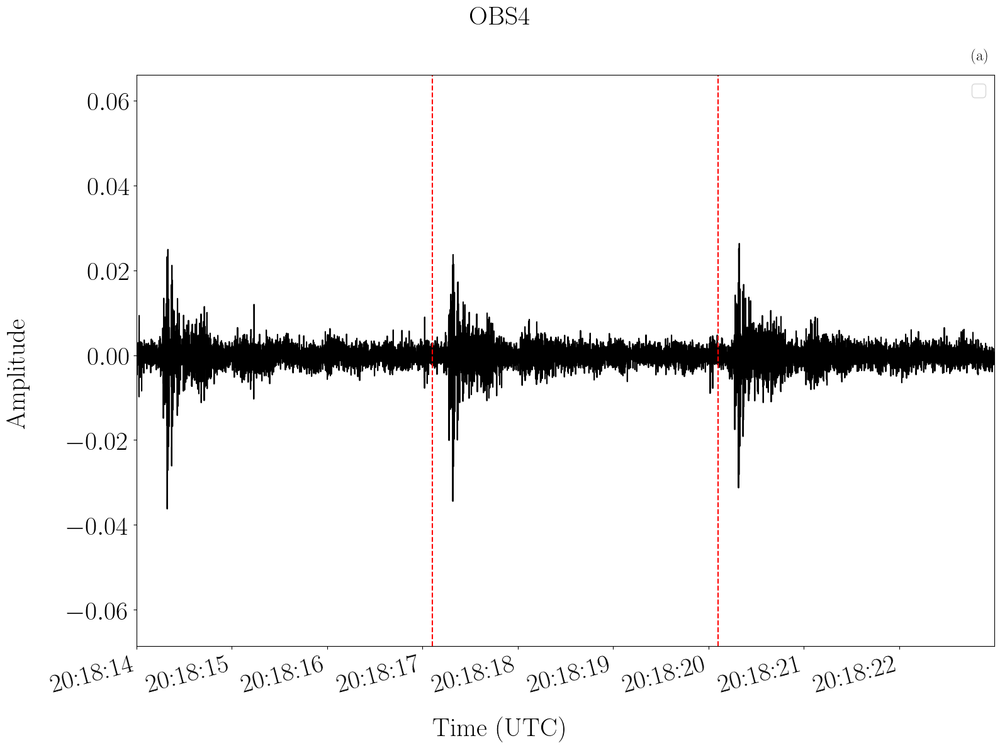

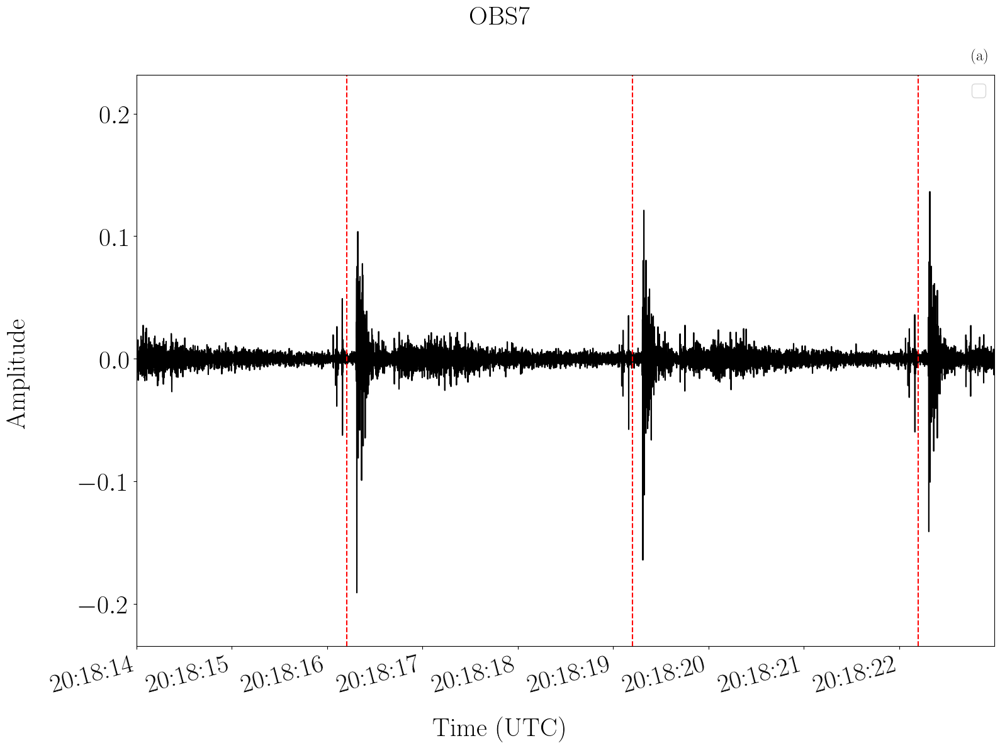

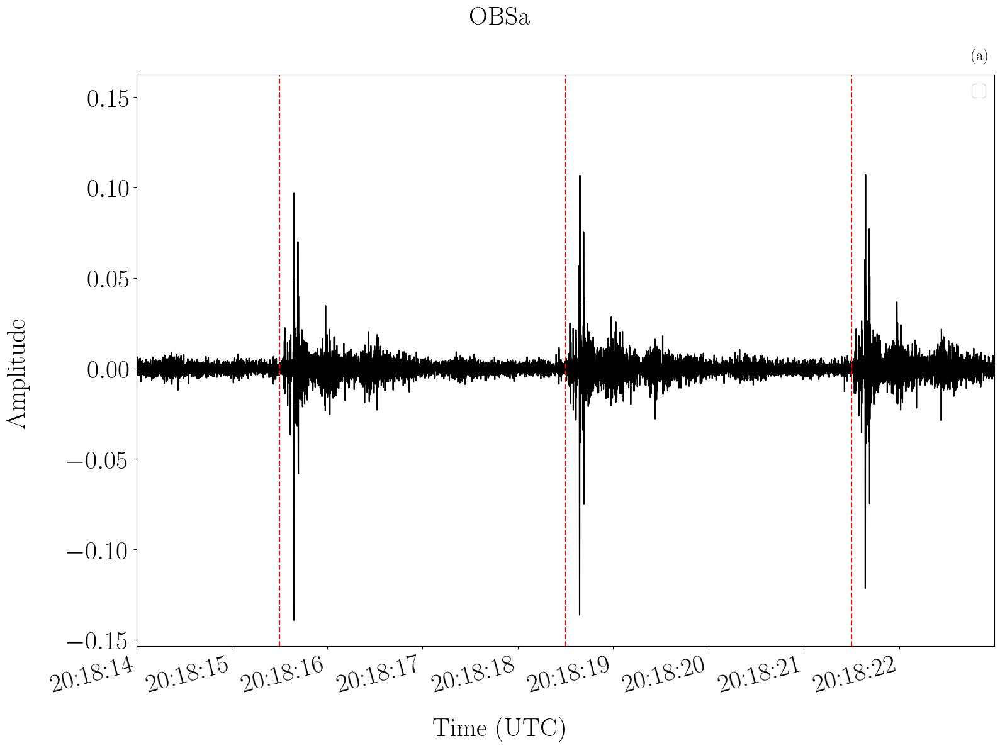

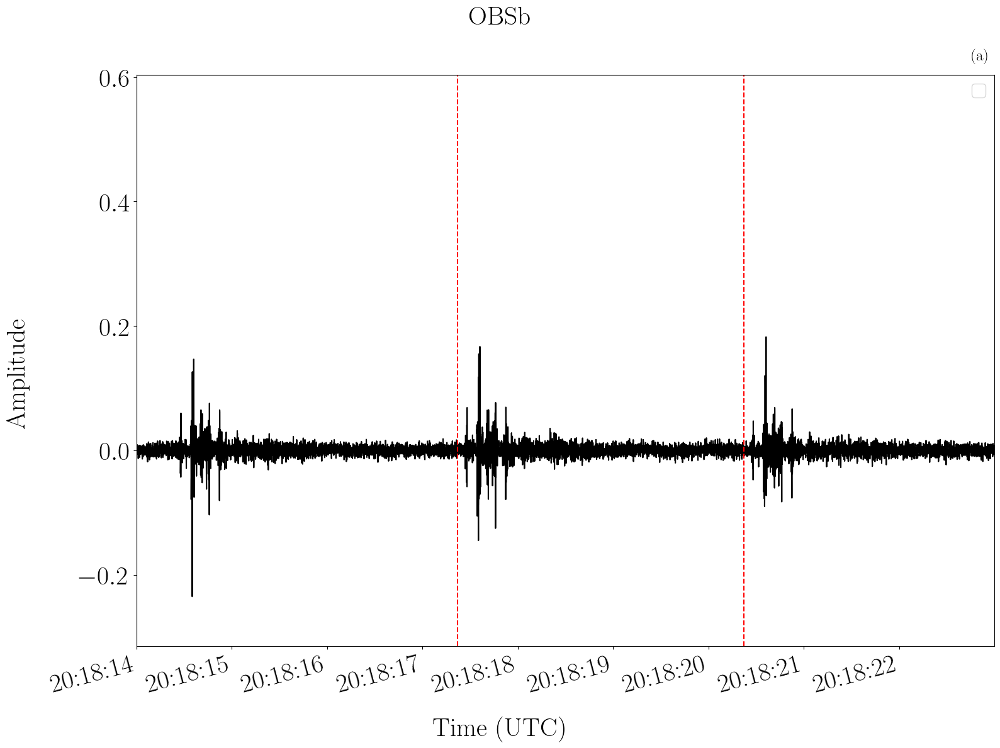

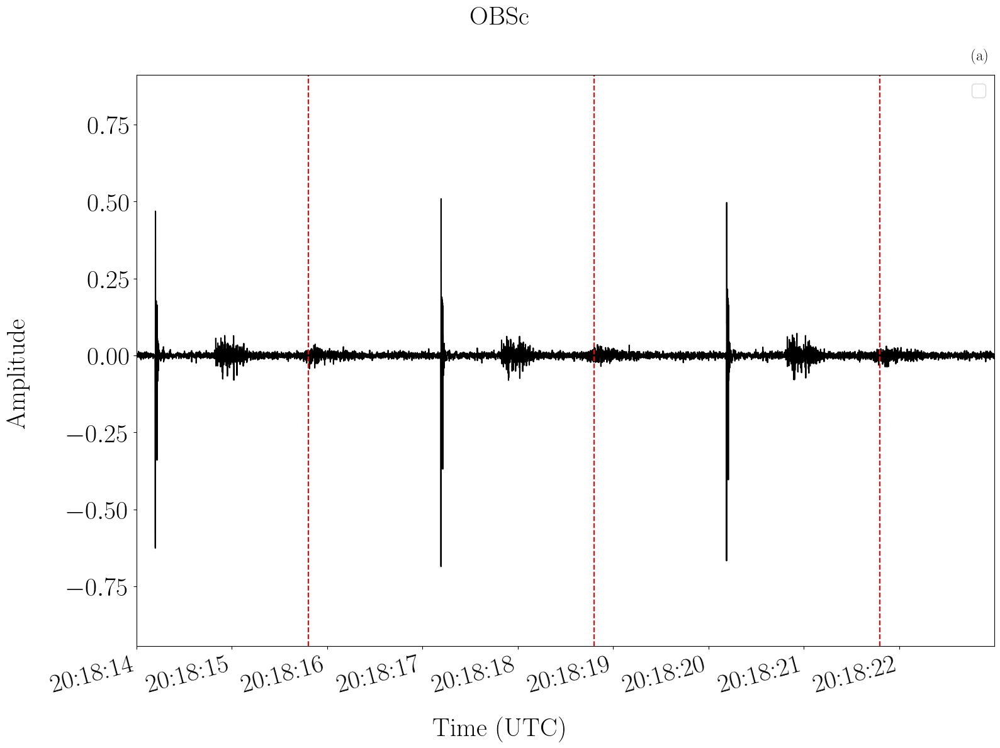

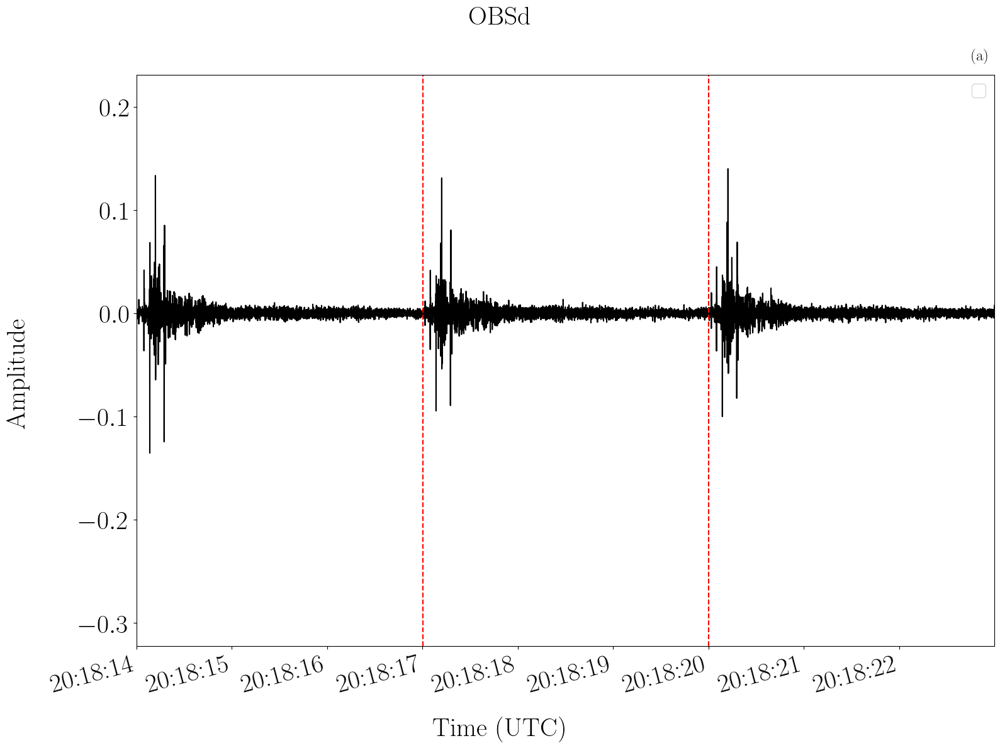

In [54]:
interval_inter_pulse_s = 3
sta_duration = 0.45
lta_duration = 3
sta_lta_threshold_obs4 = 0.5
sta_lta_threshold_obs7 = 0.85
sta_lta_threshold_obsa = 0.5
sta_lta_threshold_obsb = 0.5
sta_lta_threshold_obsc = 0.5
sta_lta_threshold_obsd = 0.5

thresholds = [
    sta_lta_threshold_obs4,
    sta_lta_threshold_obs7,
    sta_lta_threshold_obsa,
    sta_lta_threshold_obsb,
    sta_lta_threshold_obsc,
    sta_lta_threshold_obsd,
]

sig_dt, signals, arrivals_dt, arrivals_dt_idx = apply_sta_lta_only_first(
    ds_wav,
    sta_duration,
    lta_duration,
    start_dt,
    analysis_duration_s,
    thresholds,
    pulse_interval_s=interval_inter_pulse_s,
    fs=ds_wav.fs.isel(obs_id=0).values,
)

Attention, il y a une ambiguïté pour associer les paires de réceptions, il faut vérifier à l'aide des données de positions. 

In [16]:
arrivals_dt

[DatetimeIndex(['2026-02-24 20:18:17.101000', '2026-02-24 20:18:20.101000',
                '2026-02-24 20:18:23.101000', '2026-02-24 20:18:26.101000',
                '2026-02-24 20:18:29.101000', '2026-02-24 20:18:32.101000',
                '2026-02-24 20:18:35.101000', '2026-02-24 20:18:38.101000',
                '2026-02-24 20:18:41.101000', '2026-02-24 20:18:44.101000',
                ...
                '2026-02-24 20:27:44.101000', '2026-02-24 20:27:47.101000',
                '2026-02-24 20:27:50.101000', '2026-02-24 20:27:53.101000',
                '2026-02-24 20:27:56.101000', '2026-02-24 20:27:59.101000',
                '2026-02-24 20:28:02.101000', '2026-02-24 20:28:05.101000',
                '2026-02-24 20:28:08.101000', '2026-02-24 20:28:11.101000'],
               dtype='datetime64[us]', length=199, freq=None),
 DatetimeIndex(['2026-02-24 20:18:16.145500', '2026-02-24 20:18:19.145500',
                '2026-02-24 20:18:22.145500', '2026-02-24 20:18:25.145500',
    

## Estimation des RTFs 

### Estimation pour des signaux non stationnaire 

On suppose le bruit négligeable : 

$$
X_1(f) = H_1(f) S(f) + V_1(f) \approx X_1(f) = H_1(f) S(f) 
$$

et

$$
X_2(f) = H_2(f) S(f) + V_2(f) \approx X_2(f) = H_2(f) S(f) 
$$

et le rapport des fonctions de transfert est estimé par : 


$$
\Pi(f) = \frac{S_{21}(f)}{S_{11}(f)}
$$

$$
\frac{S_{21}(f)}{S_{11}(f)} = \frac{ X_2(f) \overline{X_1}(f)}{\lvert X_1 (f) \rvert} \approx \frac{H_2(f) \overline{H_1}(f) \lvert S(f) \rvert^2}{\lvert H_1 (f) \rvert^2 \lvert S(f) \rvert^2} = \frac{H_{2}(f)}{H_{1}(f)}
$$

#### Option 1 : Fenêtre temporelle commune 

Par définition le rapport doit a priori être évalué à l'aide des signaux reçus sur la même fenêtre temporelle. Néanmoins, puisque la source émet une suite de signaux impulsionnels, le choix de la fenêtre n'est pas évident. La première option envisagée est de débuter la fenêtre à l'instant de réception du signal sur le capteur le plus proche (premier temps d'arrivée). 

Le principal écueil de cette approche est le risque de considérer une partie du signal de l'émission précèdente. 

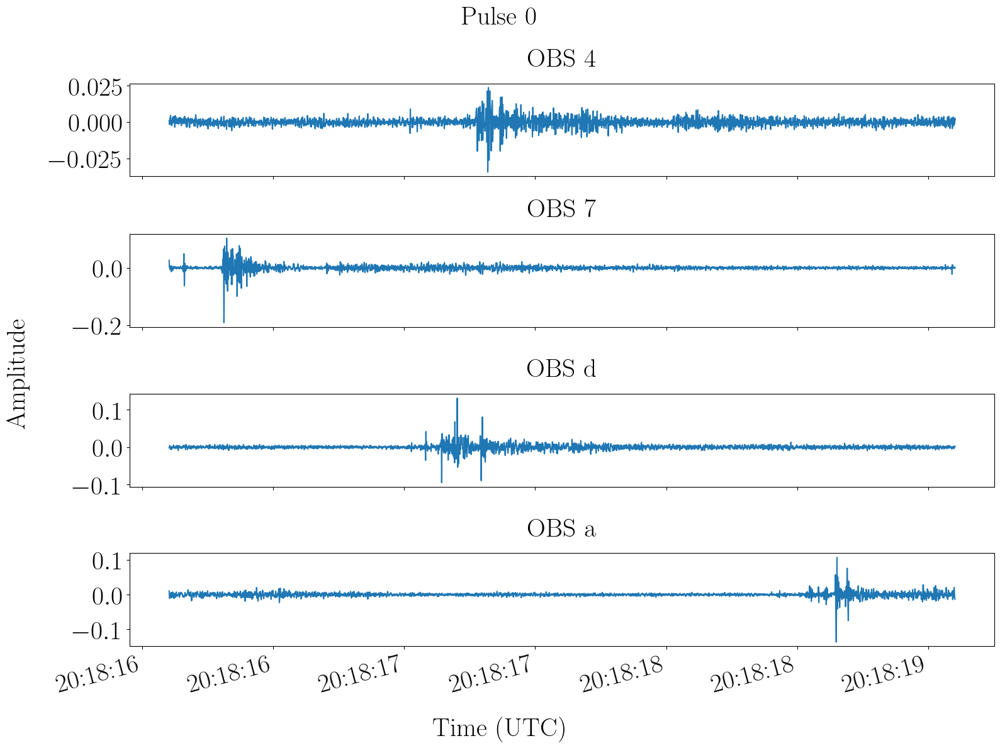

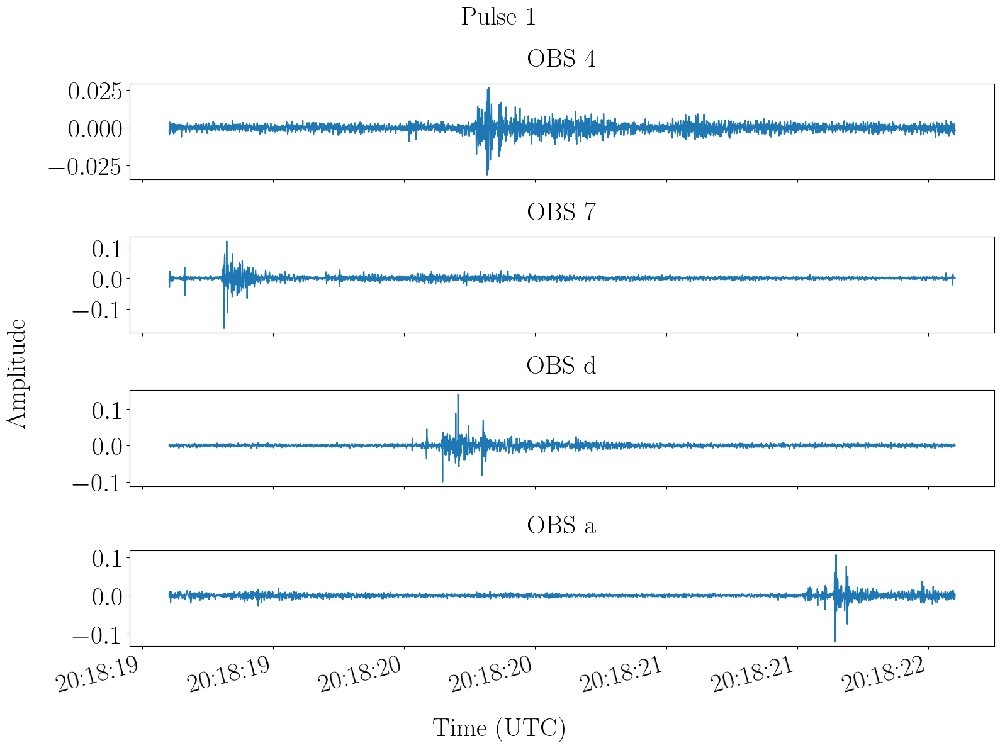

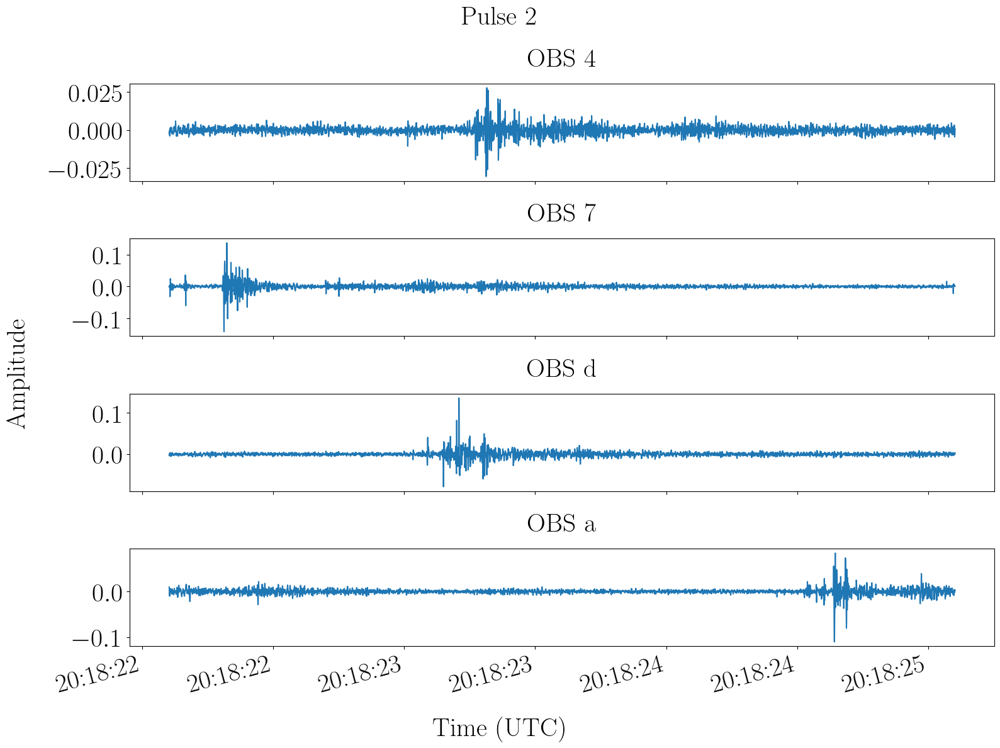

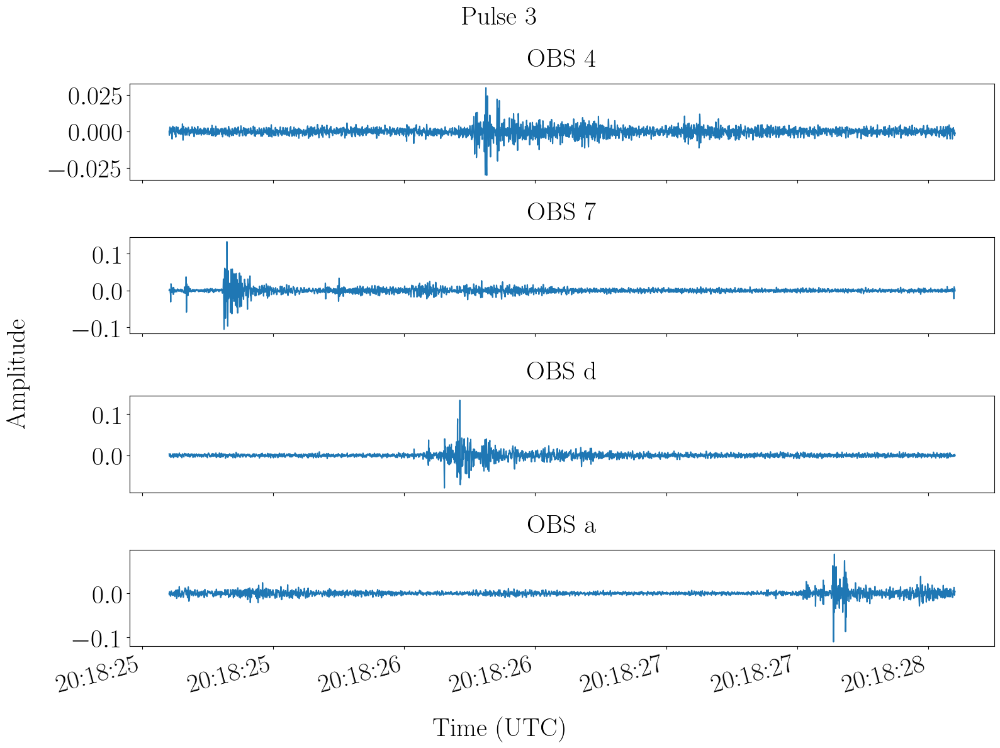

In [55]:
offset_s = 0.1
fs = 2000
n_offset = int(offset_s * fs)

# OBS 4
arr_dt_obs4 = arrivals_dt[0]
arr_dt_idx_obs4 = arrivals_dt_idx[0]
sig_obs4 = signals[0]
obs4_dt = sig_dt[0]
# OBS 7
arr_dt_obs7 = arrivals_dt[1]
arr_dt_idx_obs7 = arrivals_dt_idx[1]
sig_obs7 = signals[1]
obs7_dt = sig_dt[1]
# OBS d
arr_dt_obsd = arrivals_dt[5]
arr_dt_idx_obsd= arrivals_dt_idx[5]
sig_obsd = signals[5]
obsd_dt = sig_dt[5]
# OBS a
arr_dt_obsa = arrivals_dt[2]
arr_dt_idx_obsa = arrivals_dt_idx[2]
sig_obsa = signals[2]
obsa_dt = sig_dt[2]

# print(arr_dt_obs)
for j in range(arr_dt_obs4.size):
    # OBS 4
    arr_obs4 = arr_dt_obs4[j]
    idx_start_obs4 = arr_dt_idx_obs4[j]
    # print(arr_obs4, idx_start_obs4)

    # OBS 7
    arr_obs7 = arr_dt_obs7[j]
    idx_start_obs7 = arr_dt_idx_obs7[j]
    # print(arr_obs7, idx_start_obs7)

    # OBS d
    arr_obsd = arr_dt_obsd[j]
    idx_start_obsd = arr_dt_idx_obsd[j]

    # OBS a
    arr_obsa = arr_dt_obsa[j]
    idx_start_obsa = arr_dt_idx_obsa[j]

    if arr_obs4 <= arr_obs7:
        pulse_start_dt = arr_obs4
        pulse_start_idx = idx_start_obs4
    else:
        pulse_start_dt = arr_obs7
        pulse_start_idx = idx_start_obs7

    # Extract pulse : option 1
    pulse_start_idx = pulse_start_idx - n_offset
    pulse_end_idx = pulse_start_idx + int(interval_inter_pulse_s * fs)
    pulse_obs4 = sig_obs4[pulse_start_idx:pulse_end_idx]
    pulse_obs7 = sig_obs7[pulse_start_idx:pulse_end_idx]
    pulse_obsd = sig_obsd[pulse_start_idx:pulse_end_idx]
    pulse_obsa = sig_obsa[pulse_start_idx:pulse_end_idx]

    pulse_start_idx_obs4, pulse_end_idx_obs4 = pulse_start_idx, pulse_end_idx
    pulse_start_idx_obs7, pulse_end_idx_obs7 = pulse_start_idx, pulse_end_idx
    pulse_start_idx_obsd, pulse_end_idx_obsd = pulse_start_idx, pulse_end_idx
    pulse_start_idx_obsa, pulse_end_idx_obsa = pulse_start_idx, pulse_end_idx

    # # Extract pulse
    # pulse_start_idx_obs4 = idx_start_obs4 - n_offset
    # pulse_end_idx_obs4 = pulse_start_idx_obs4 + int(interval_inter_pulse_s * fs)
    # pulse_obs4 = sig_obs4[pulse_start_idx_obs4:pulse_end_idx_obs4]

    # pulse_start_idx_obs7 = idx_start_obs7 - n_offset
    # pulse_end_idx_obs7 = pulse_start_idx_obs7 + int(interval_inter_pulse_s * fs)
    # pulse_obs7 = sig_obs7[pulse_start_idx_obs7:pulse_end_idx_obs7]

    if j < 4:
        fig, axs = plt.subplots(4, 1, sharex=True, figsize=(16, 12))
        axs = np.atleast_1d(axs)

        axs[0].plot(obs4_dt[pulse_start_idx_obs4:pulse_end_idx_obs4], pulse_obs4)
        axs[0].set_title("OBS 4")
        axs[1].plot(obs7_dt[pulse_start_idx_obs7:pulse_end_idx_obs7], pulse_obs7)
        axs[1].set_title("OBS 7")
        axs[2].plot(obsd_dt[pulse_start_idx_obsd:pulse_end_idx_obsd], pulse_obsd)
        axs[2].set_title("OBS d")
        axs[3].plot(obsa_dt[pulse_start_idx_obsa:pulse_end_idx_obsa], pulse_obsa)
        axs[3].set_title("OBS a")

        fig.suptitle(f"Pulse {j}")

        formatter = mdates.DateFormatter("%H:%M:%S")
        axs[-1].xaxis.set_major_formatter(formatter)
        formatter = mdates.DateFormatter("%H:%M:%S")
        axs[-1].xaxis.set_major_formatter(formatter)
        locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
        axs[-1].xaxis.set_major_locator(locator)
        plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

        fig.supylabel("Amplitude")
        fig.supxlabel("Time (UTC)")


Ici, le signal est d'abord reçu sur l'OBS 4 puis sur l'OBS 7 (ou inversement, cf remarque sur l'ambiguïté ci-dessus). Ainsi, la première partie du signal considéré pour l'OBS 7 correspond à l'émission précédente (et donc à la position de source précédente). 

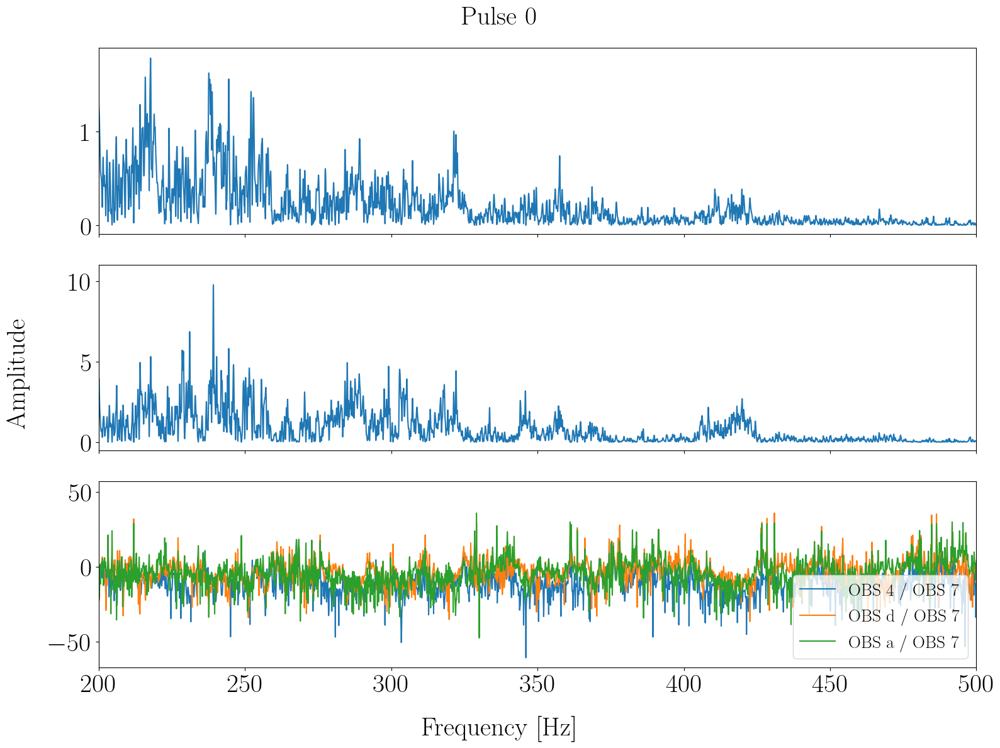

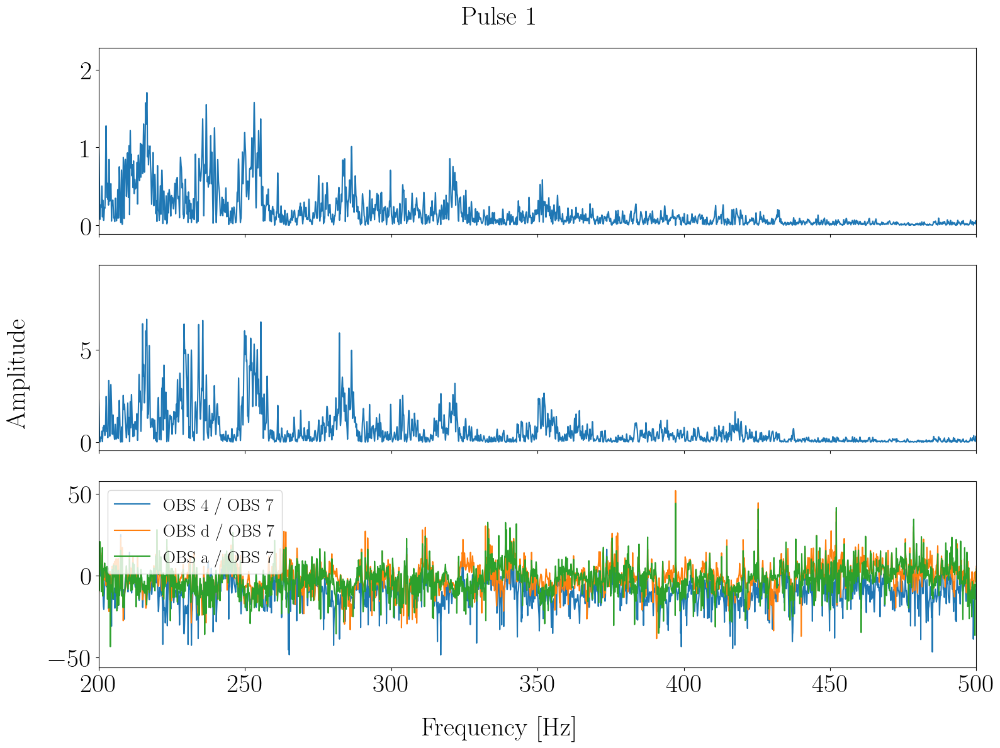

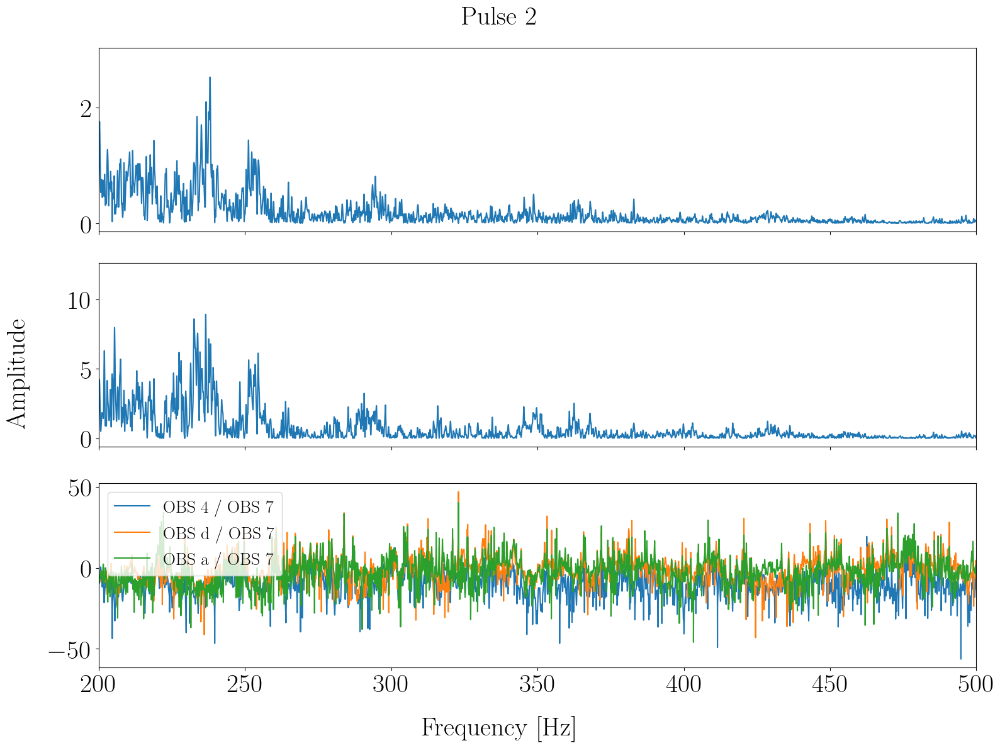

In [56]:
pi47 = []
pid7 = []
pia7 = []

pi_roll = []
npulse = arr_dt_obs4.size
for j in range(npulse):
    # OBS 4
    arr_obs4 = arr_dt_obs4[j]
    idx_start_obs4 = arr_dt_idx_obs4[j]
    # print(arr_obs4, idx_start_obs4)

    # OBS 7
    arr_obs7 = arr_dt_obs7[j]
    idx_start_obs7 = arr_dt_idx_obs7[j]
    # print(arr_obs7, idx_start_obs7)

    # OBS d
    arr_obsd = arr_dt_obsd[j]
    idx_start_obsd = arr_dt_idx_obsd[j]

    # OBS a
    arr_obsa = arr_dt_obsa[j]
    idx_start_obsa = arr_dt_idx_obsa[j]

    if arr_obs4 <= arr_obs7:
        pulse_start_dt = arr_obs4
        pulse_start_idx = idx_start_obs4
    else:
        pulse_start_dt = arr_obs7
        pulse_start_idx = idx_start_obs7

    # Extract pulse : option 1
    pulse_start_idx = pulse_start_idx - n_offset
    pulse_end_idx = pulse_start_idx + int(interval_inter_pulse_s * fs)
    pulse_obs4 = sig_obs4[pulse_start_idx:pulse_end_idx]
    pulse_obs7 = sig_obs7[pulse_start_idx:pulse_end_idx]
    pulse_obsd = sig_obsd[pulse_start_idx:pulse_end_idx]
    pulse_obsa = sig_obsa[pulse_start_idx:pulse_end_idx]

    pulse_start_idx_obs4, pulse_end_idx_obs4 = pulse_start_idx, pulse_end_idx
    pulse_start_idx_obs7, pulse_end_idx_obs7 = pulse_start_idx, pulse_end_idx
    pulse_start_idx_obsd, pulse_end_idx_obsd = pulse_start_idx, pulse_end_idx
    pulse_start_idx_obsa, pulse_end_idx_obsa = pulse_start_idx, pulse_end_idx

    # # Extract pulse
    # pulse_start_idx_obs4 = idx_start_obs4 - n_offset
    # pulse_end_idx_obs4 = pulse_start_idx_obs4 + int(interval_inter_pulse_s * fs)
    # pulse_obs4 = sig_obs4[pulse_start_idx_obs4:pulse_end_idx_obs4]

    # pulse_start_idx_obs7 = idx_start_obs7 - n_offset
    # pulse_end_idx_obs7 = pulse_start_idx_obs7 + int(interval_inter_pulse_s * fs)
    # pulse_obs7 = sig_obs7[pulse_start_idx_obs7:pulse_end_idx_obs7]

    # Compute cross spectrum S12 = X1 conj(X2)
    nfft = 2**16
    f_fft = np.fft.rfftfreq(nfft, d=1 / fs)
    
    fft_obs4 = np.fft.rfft(pulse_obs4, n=nfft)
    fft_obs7 = np.fft.rfft(pulse_obs7, n=nfft)
    fft_obsd = np.fft.rfft(pulse_obsd, n=nfft)
    fft_obsa = np.fft.rfft(pulse_obsa, n=nfft)

    sxy = fft_obs4 * np.conj(fft_obs7)
    syy = fft_obs7 * np.conj(fft_obs7)
    sdy = fft_obsd * np.conj(fft_obs7)
    say = fft_obsa * np.conj(fft_obs7)

    # OBS 4 / OBS 7
    pi_47 = sxy / syy
    pi47.append(pi_47)
    # OBS d / OBS 7
    pi_d7 = sdy / syy
    pid7.append(pi_d7)
    # OBS a / OBS 7
    pi_a7 = say / syy
    pia7.append(pi_a7)

    N = 5
    pi_roll_ = np.convolve(20 * np.log10(np.abs(pi_47)), np.ones(N) / N, mode="same")
    pi_roll.append(pi_roll_)

    if j < 3:
        fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
        axs = np.atleast_1d(axs)

        axs[0].plot(f_fft, np.abs(sxy))
        axs[1].plot(f_fft, np.abs(syy))
        axs[2].plot(f_fft, 20 * np.log10(np.abs(pi_47)), label="OBS 4 / OBS 7")
        axs[2].plot(f_fft, 20 * np.log10(np.abs(pi_d7)), label="OBS d / OBS 7")
        axs[2].plot(f_fft, 20 * np.log10(np.abs(pi_a7)), label="OBS a / OBS 7")

        # axs[2].plot(f_fft, pi_roll_)
        fig.suptitle(f"Pulse {j}")

        fig.supylabel("Amplitude")
        fig.supxlabel("Frequency [Hz]")

        plt.xlim(200,500)
        plt.legend()

In [57]:
pi47 = np.array(pi47)
pid7 = np.array(pid7)
pia7 = np.array(pia7)
pi_roll = np.array(pi_roll)
rep_id = np.arange(npulse)

In [58]:
pi2_47 = 20 * np.log10(np.abs(pi47))
pi2_d7 = 20 * np.log10(np.abs(pid7))
pi2_a7 = 20 * np.log10(np.abs(pia7))

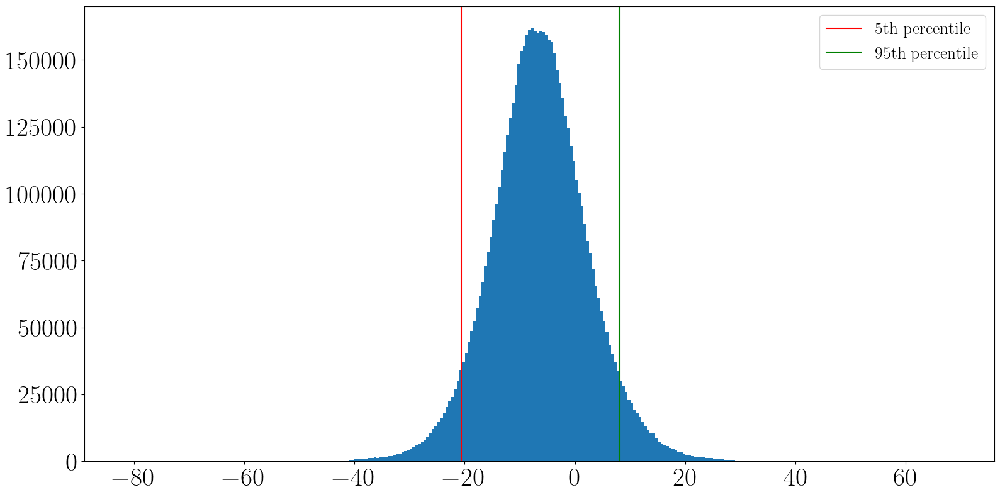

In [59]:
plt.hist(pi2_47.flatten(), bins=300)
plt.axvline(np.percentile(pi2_47.flatten(), 5), color="r", label="5th percentile")
plt.axvline(np.percentile(pi2_47.flatten(), 95), color="g", label="95th percentile")
plt.legend()


Text(0.5, 1.0, 'OBS a / OBS 7')

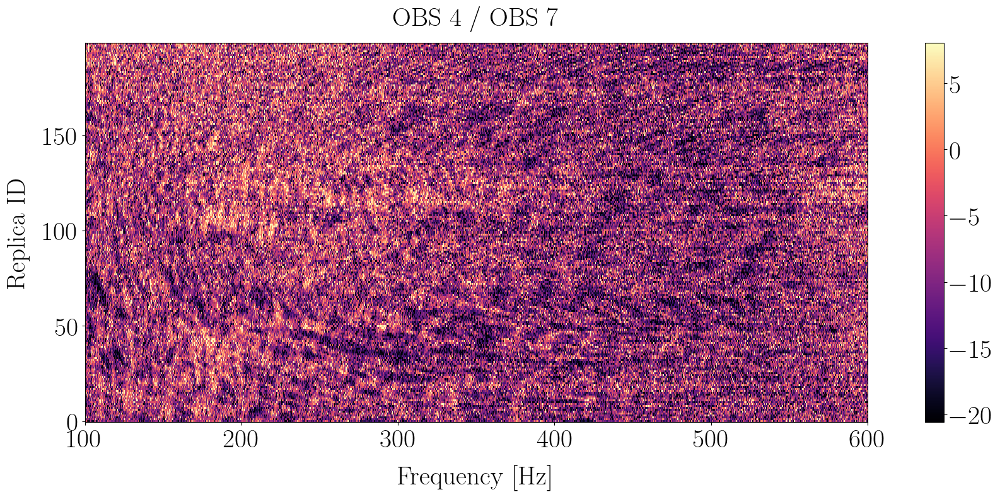

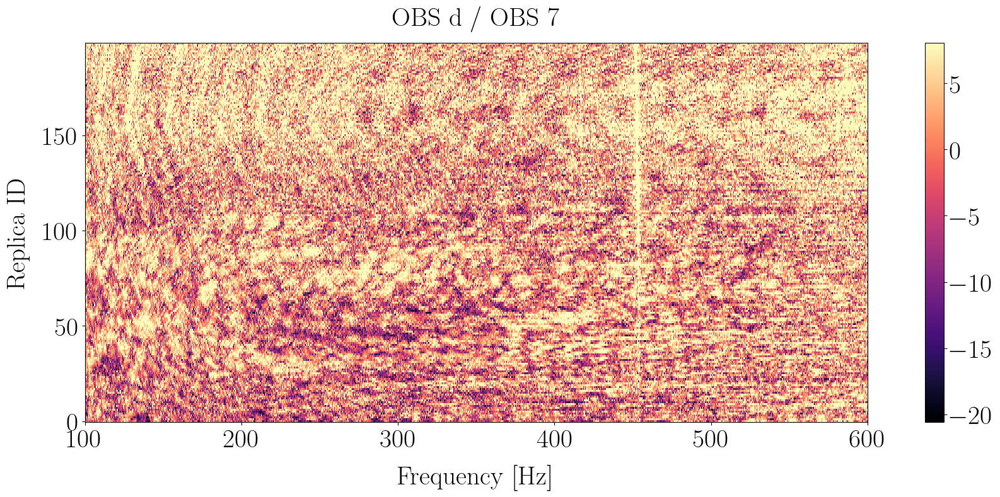

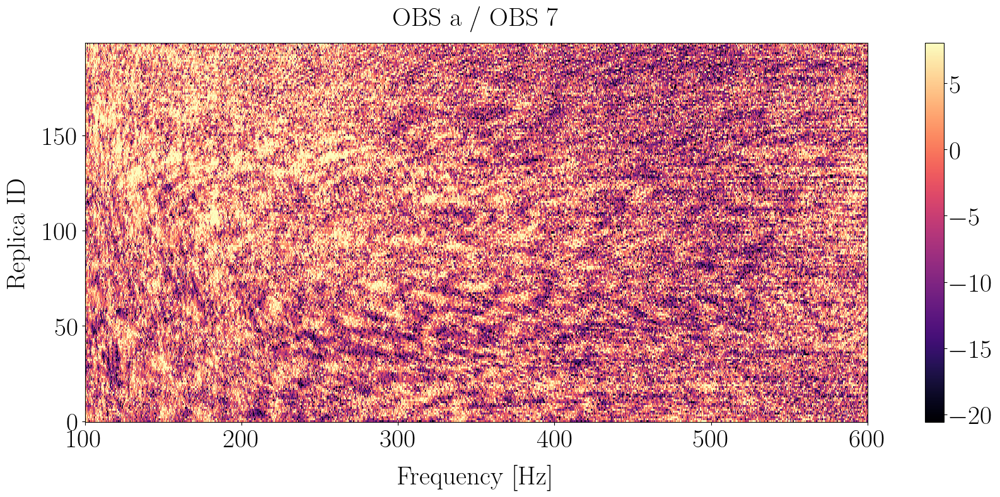

In [60]:
vmin = np.percentile(pi2_47, 5)
vmax = np.percentile(pi2_47, 95)

plt.figure()
im = plt.pcolormesh(
    f_fft,
    rep_id,
    pi2_47,
    cmap="magma",
    vmin=vmin, 
    vmax=vmax,
)
plt.xlim(100, 600)
# plt.ylim(50, 400)
plt.colorbar(im)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Replica ID")
plt.title("OBS 4 / OBS 7")

plt.figure()
im = plt.pcolormesh(
    f_fft,
    rep_id,
    pi2_d7,
    cmap="magma",
    vmin=vmin,
    vmax=vmax,
)
plt.xlim(100, 600)
# plt.ylim(50, 400)
plt.colorbar(im)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Replica ID")
plt.title("OBS d / OBS 7")

plt.figure()
im = plt.pcolormesh(
    f_fft,
    rep_id,
    pi2_a7,
    cmap="magma",
    vmin=vmin,
    vmax=vmax,
)
plt.xlim(100, 600)
# plt.ylim(50, 400)
plt.colorbar(im)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Replica ID")
plt.title("OBS a / OBS 7")

On peut observer un joli motif au passage du CPA d'un des OBS. Un point important, le motif évolue plutôt lentement contrairement à ce que l'on observe en petit fond à Groix.  

Le motif est similaire sur les capteurs 4, a, d. 

In [61]:
diff_pi2_47_a7 = pi2_47 - pi2_a7
diff_pi2_47_d7 = pi2_47 - pi2_d7
diff_pi2_d7_a7 = pi2_d7 - pi2_a7

Text(0.5, 1.0, 'OBS d / OBS 7 - OBS a / OBS 7')

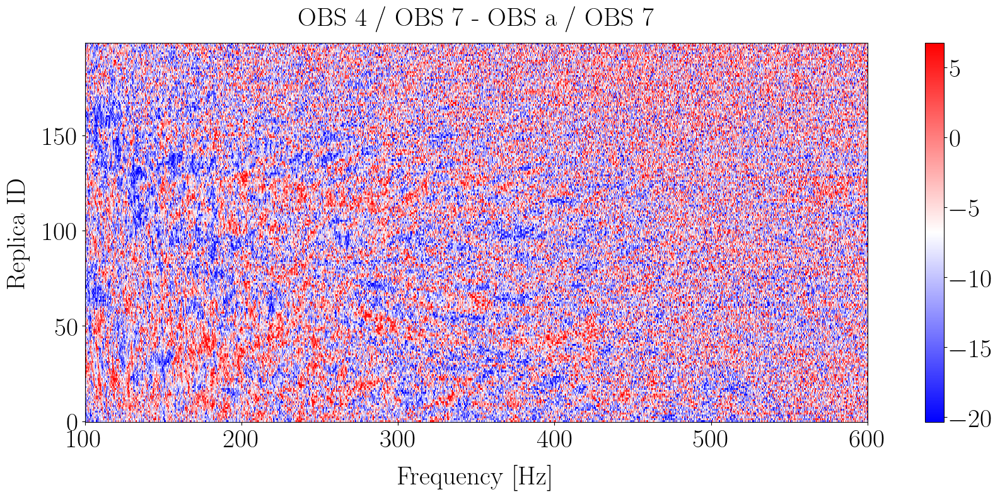

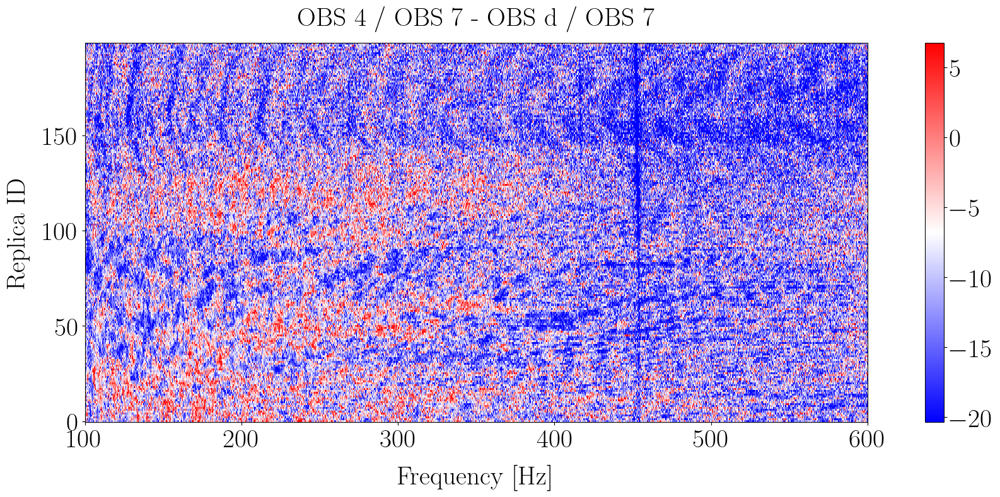

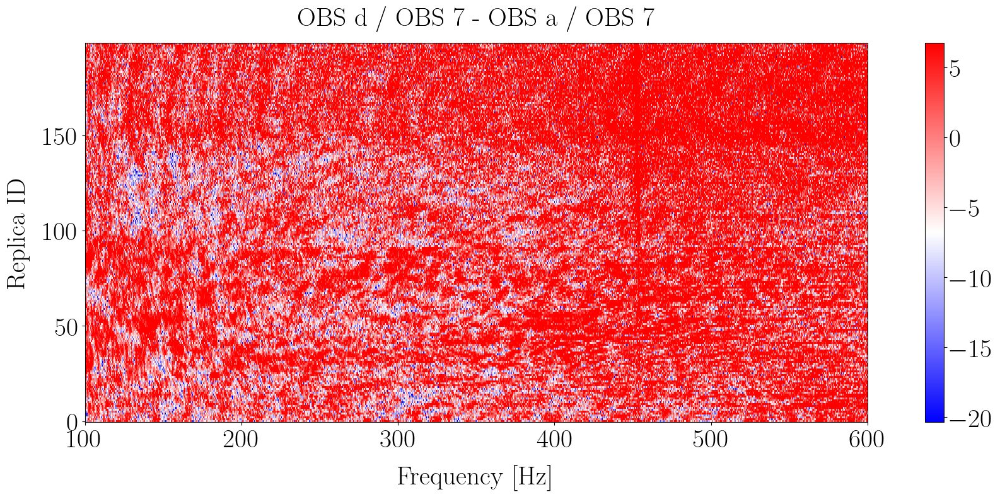

In [62]:
vmin = np.percentile(diff_pi2_47_a7, 5)
vmax = np.percentile(diff_pi2_47_a7, 95)

plt.figure()
im = plt.pcolormesh(
    f_fft,
    rep_id,
    diff_pi2_47_a7,
    cmap="bwr",
    vmin=vmin,
    vmax=vmax,
)
plt.xlim(100, 600)
# plt.ylim(50, 400)
plt.colorbar(im)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Replica ID")
plt.title("OBS 4 / OBS 7 - OBS a / OBS 7")

plt.figure()
im = plt.pcolormesh(
    f_fft,
    rep_id,
    diff_pi2_47_d7,
    cmap="bwr",
    vmin=vmin,
    vmax=vmax,
)
plt.xlim(100, 600)
# plt.ylim(50, 400)
plt.colorbar(im)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Replica ID")
plt.title("OBS 4 / OBS 7 - OBS d / OBS 7")

plt.figure()
im = plt.pcolormesh(
    f_fft,
    rep_id,
    diff_pi2_d7_a7,
    cmap="bwr",
    vmin=vmin,
    vmax=vmax,
)
plt.xlim(100, 600)
# plt.ylim(50, 400)
plt.colorbar(im)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Replica ID")
plt.title("OBS d / OBS 7 - OBS a / OBS 7")

Quelle que soit la position de la source considérée les capteurs encodent néanmoins bien une information différente. 

In [63]:
# pi2_roll = 20 * np.log10(np.abs(pi_roll))
# plt.figure()
# im = plt.pcolormesh(
#     f_fft,
#     rep_id,
#     pi2_roll,
#     cmap="magma",
#     vmin=-15,
#     vmax=50,
#     # vmin=np.percentile(pi2, 0.001),
#     # vmax=np.percentile(pi2, 0.99999),
# )
# plt.xlim(100, 600)
# plt.colorbar(im)

#### Option 2 : Fenêtre shiftée 

Une seconde approche consiste à considérer une fenêtre de durée T débutant à l'instant d'arrivée du signal de manière indépendante pour chacun des récepteurs. Ainsi, le signal ne contient que l'émission désirée. 

Mathématiquement, cela ne change rien. En effet, la réponse impulsionnelle du canal consiste en une durée $\tau$ de silence correspondant au temps de propagation du direct puis en une série de diracs correspond aux différentes arrivées. La réponse impulsionnelle est à support temporel fini et se termine donc par des 0 (si tenté que l'on regarde suffisamment loin, après le temps caractéristique de réverbération par exemple).    
Ainsi, pour des émissions successives suffisamment espacées dans le temps (temps inter pulse supérieur à la durée de la réponse impulsionnelle) le choix d'une telle fenêtre ne change rien d'un point de vue du module du rapport des fonctions de transfert. 

$$
\tilde{H_1}(f) = H_1(f) \times e^{+i2\pi f \tau}
$$

et 
$$
\tilde{\Pi}(f) = \frac{H_2(f)}{\tilde{H_1}(f)} = \frac{H_2(f)}{H_1(f)} \times e^{-i2\pi f \tau} 
$$

et

$$
\lvert \tilde{\Pi}(f) \rvert = \lvert \Pi(f) \rvert

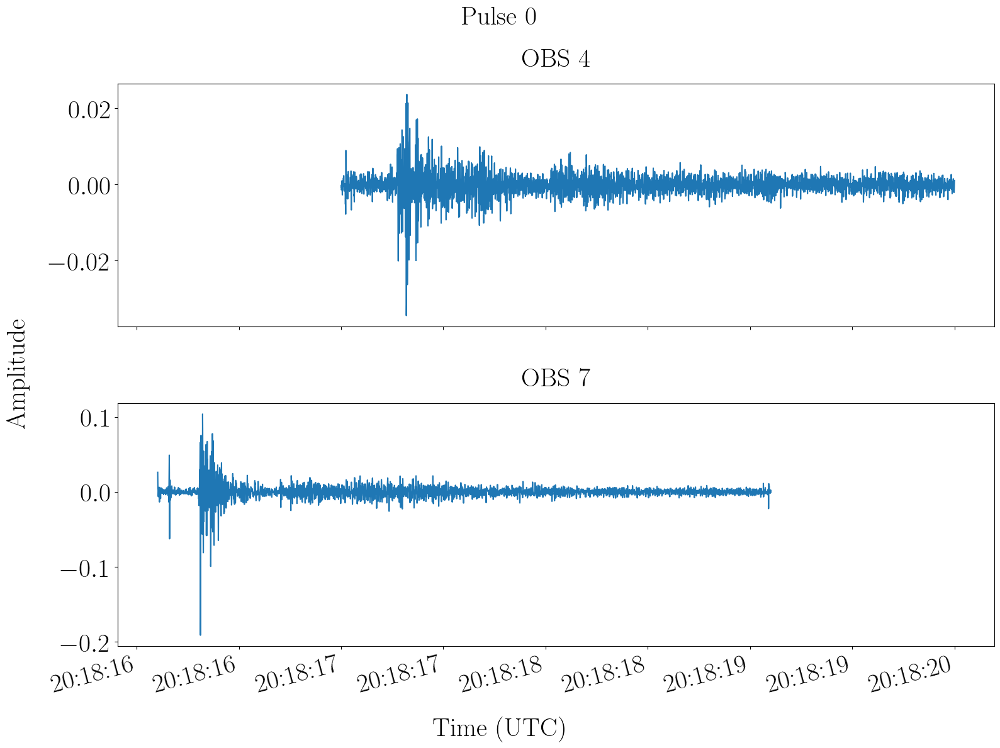

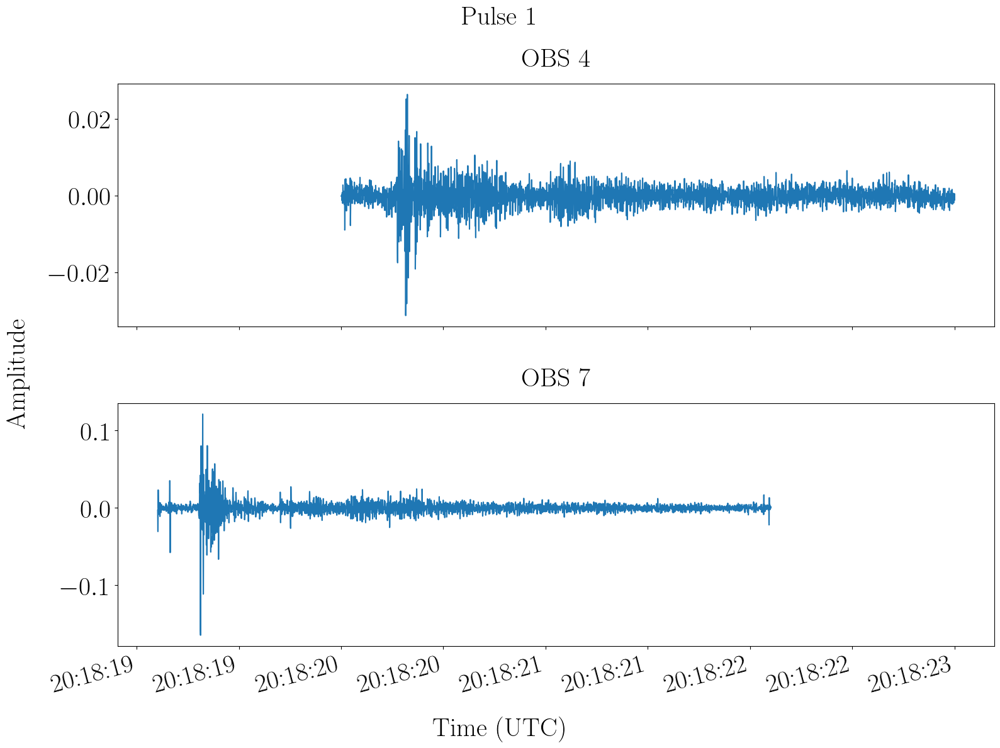

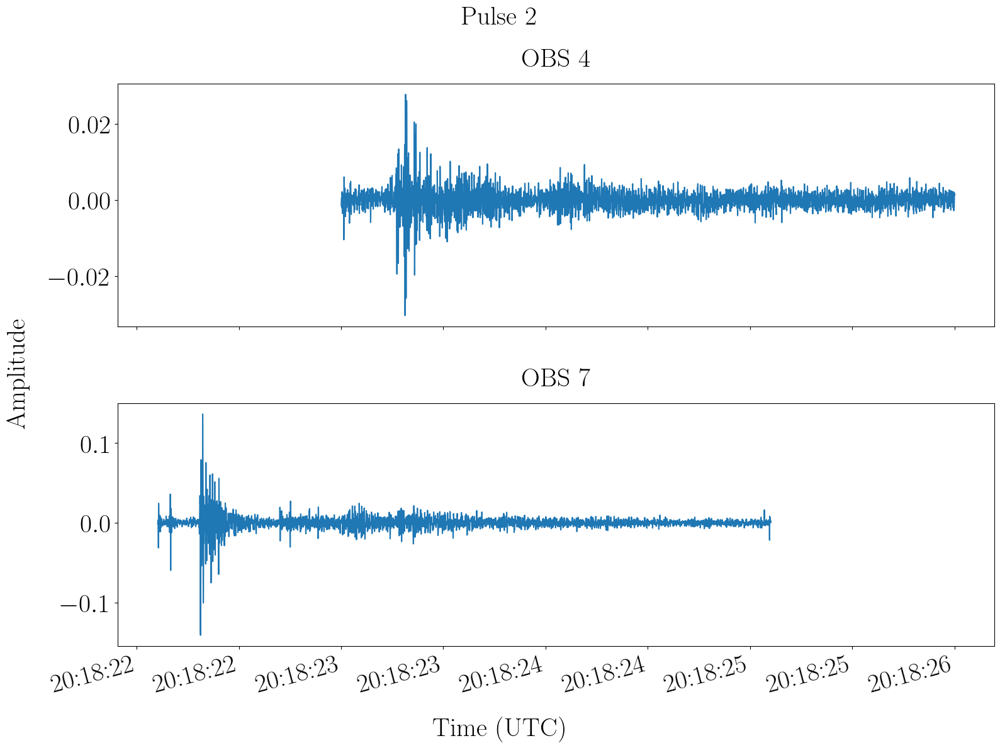

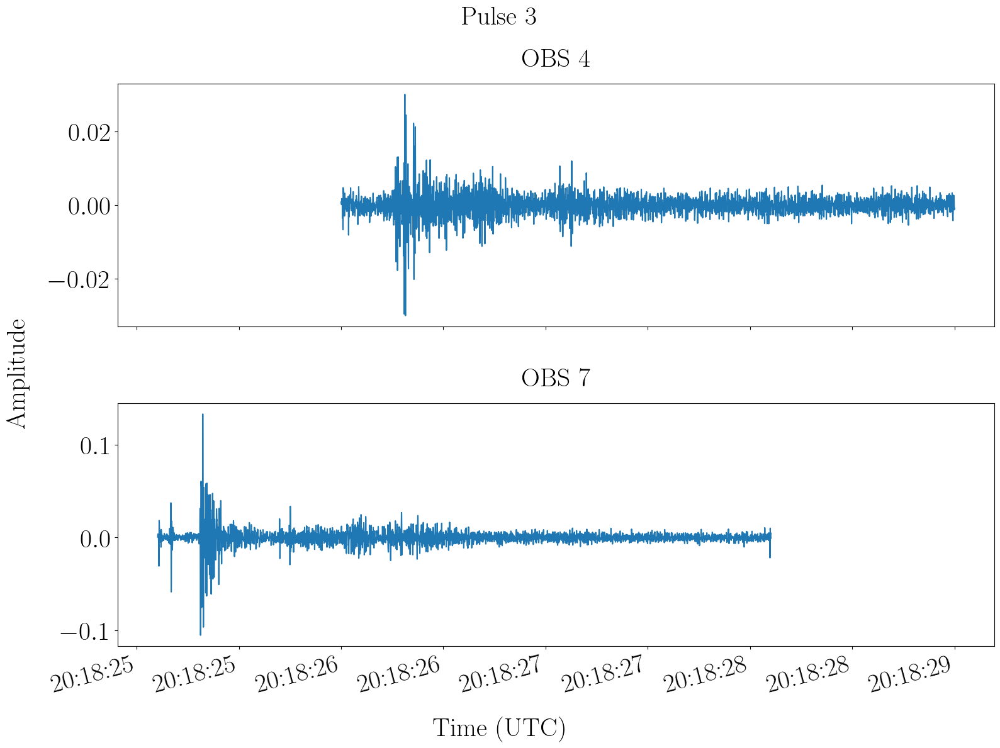

In [64]:
offset_s = 0.1
fs = 2000
n_offset = int(offset_s * fs)

arr_dt_obs4 = arrivals_dt[0]
arr_dt_idx_obs4 = arrivals_dt_idx[0]
arr_dt_obs7 = arrivals_dt[1]
arr_dt_idx_obs7 = arrivals_dt_idx[1]

sig_obs4 = signals[0]
obs4_dt = sig_dt[0]
sig_obs7 = signals[1]
obs7_dt = sig_dt[1]

# print(arr_dt_obs)
for j in range(arr_dt_obs4.size):
    # OBS 4
    arr_obs4 = arr_dt_obs4[j]
    idx_start_obs4 = arr_dt_idx_obs4[j]
    # print(arr_obs4, idx_start_obs4)

    # OBS 7
    arr_obs7 = arr_dt_obs7[j]
    idx_start_obs7 = arr_dt_idx_obs7[j]
    # print(arr_obs7, idx_start_obs7)

    if arr_obs4 <= arr_obs7:
        pulse_start_dt = arr_obs4
        pulse_start_idx = idx_start_obs4
    else:
        pulse_start_dt = arr_obs7
        pulse_start_idx = idx_start_obs7

    # # Extract pulse : option 1
    # pulse_start_idx = pulse_start_idx - n_offset
    # pulse_end_idx = pulse_start_idx + int(interval_inter_pulse_s * fs)
    # pulse_obs4 = sig_obs4[pulse_start_idx:pulse_end_idx]
    # pulse_obs7 = sig_obs7[pulse_start_idx:pulse_end_idx]

    # pulse_start_idx_obs4, pulse_end_idx_obs4 = pulse_start_idx, pulse_end_idx
    # pulse_start_idx_obs7, pulse_end_idx_obs7 = pulse_start_idx, pulse_end_idx

    # Extract pulse : option 2
    pulse_start_idx_obs4 = idx_start_obs4 - n_offset
    pulse_end_idx_obs4 = pulse_start_idx_obs4 + int(interval_inter_pulse_s * fs)
    pulse_obs4 = sig_obs4[pulse_start_idx_obs4:pulse_end_idx_obs4]

    pulse_start_idx_obs7 = idx_start_obs7 - n_offset
    pulse_end_idx_obs7 = pulse_start_idx_obs7 + int(interval_inter_pulse_s * fs)
    pulse_obs7 = sig_obs7[pulse_start_idx_obs7:pulse_end_idx_obs7]

    if j < 4:
        fig, axs = plt.subplots(2, 1, sharex=True, figsize=(16, 12))
        axs = np.atleast_1d(axs)

        axs[0].plot(obs4_dt[pulse_start_idx_obs4:pulse_end_idx_obs4], pulse_obs4)
        axs[0].set_title("OBS 4")
        axs[1].plot(obs7_dt[pulse_start_idx_obs7:pulse_end_idx_obs7], pulse_obs7)
        axs[1].set_title("OBS 7")

        fig.suptitle(f"Pulse {j}")

        formatter = mdates.DateFormatter("%H:%M:%S")
        axs[-1].xaxis.set_major_formatter(formatter)
        formatter = mdates.DateFormatter("%H:%M:%S")
        axs[-1].xaxis.set_major_formatter(formatter)
        locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
        axs[-1].xaxis.set_major_locator(locator)
        plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")

        fig.supylabel("Amplitude")
        fig.supxlabel("Time (UTC)")

    # print(pulse_start_idx,pulse_end_idx)
    # print(obs4_dt[pulse_start_idx:pulse_end_idx])

    # pulse_obs4 =

Ici, le signal est d'abord reçu sur l'OBS 4 puis sur l'OBS 7 (ou inversement, cf remarque sur l'ambiguïté ci-dessus). Ainsi, la première partie du signal considéré pour l'OBS 7 correspond à l'émission précédente (et donc à la position de source précédente). 

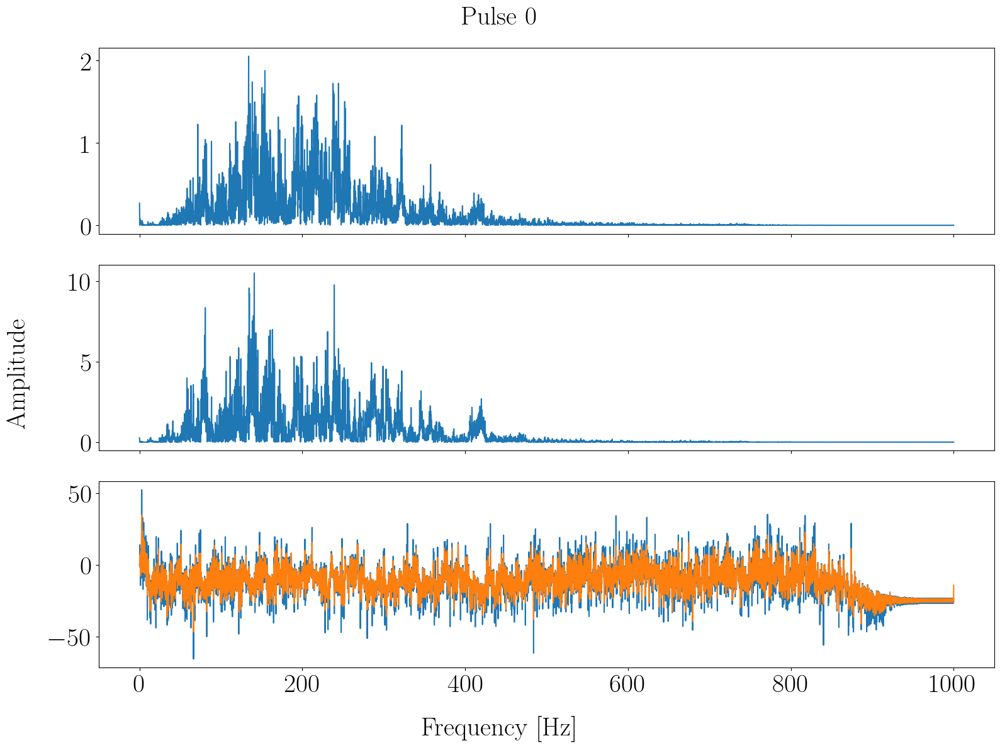

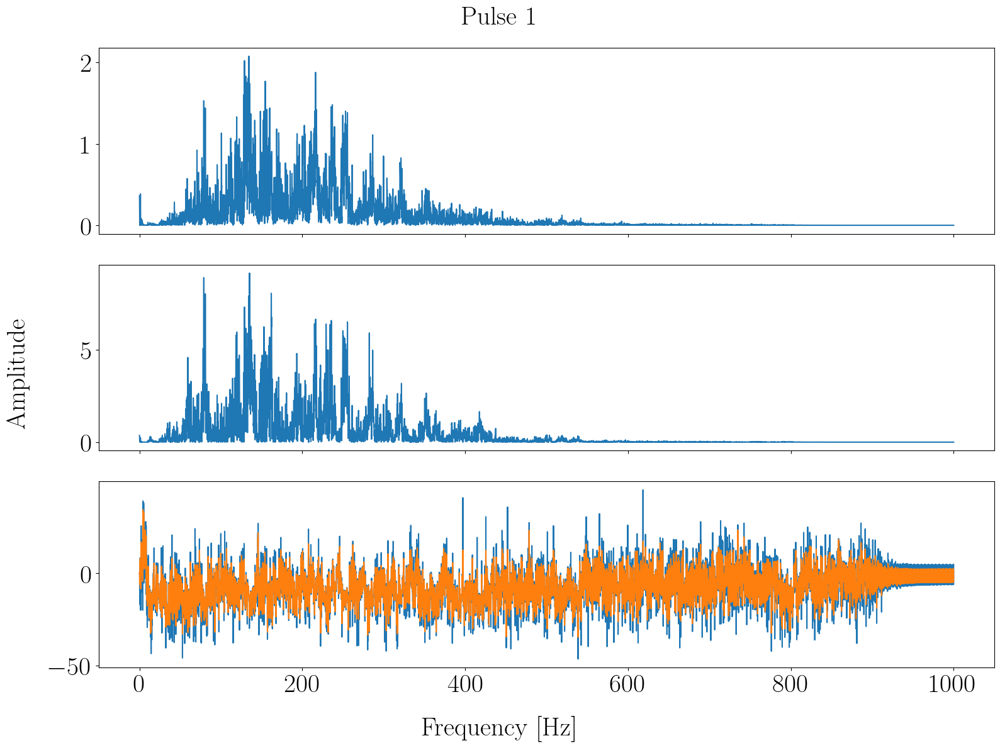

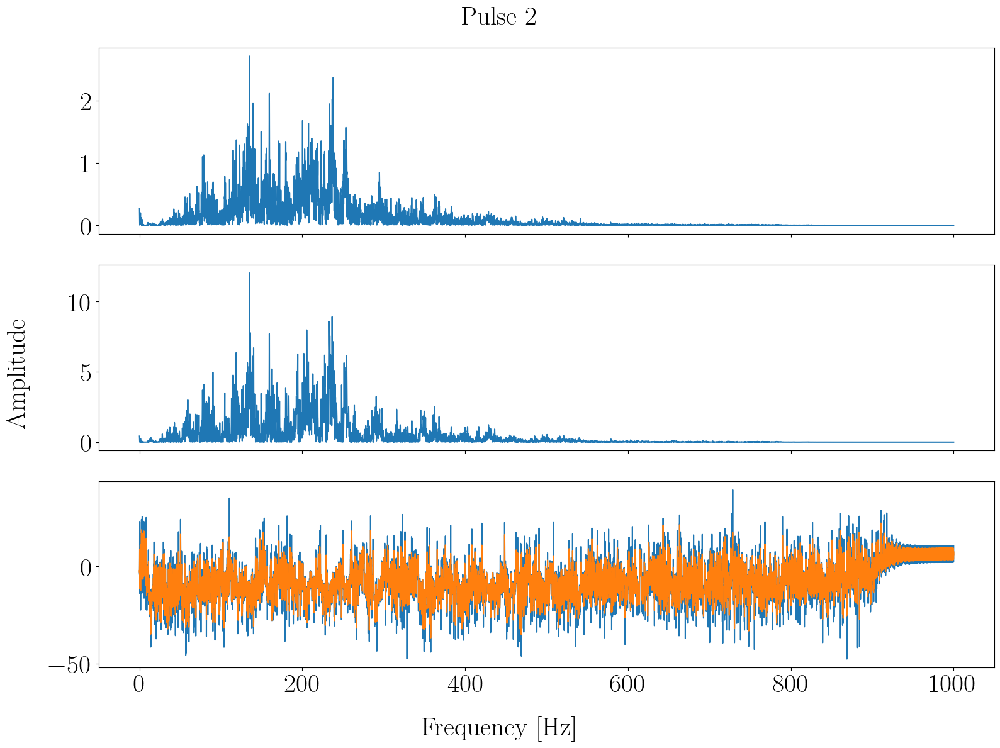

In [65]:
pi_tilde = []
pi_roll = []
npulse = arr_dt_obs4.size
for j in range(npulse):
    # OBS 4
    arr_obs4 = arr_dt_obs4[j]
    idx_start_obs4 = arr_dt_idx_obs4[j]
    # print(arr_obs4, idx_start_obs4)

    # OBS 7
    arr_obs7 = arr_dt_obs7[j]
    idx_start_obs7 = arr_dt_idx_obs7[j]
    # print(arr_obs7, idx_start_obs7)

    if arr_obs4 <= arr_obs7:
        pulse_start_dt = arr_obs4
        pulse_start_idx = idx_start_obs4
    else:
        pulse_start_dt = arr_obs7
        pulse_start_idx = idx_start_obs7

    # # Extract pulse : option 1
    # pulse_start_idx = pulse_start_idx - n_offset
    # pulse_end_idx = pulse_start_idx + int(interval_inter_pulse_s * fs)
    # pulse_obs4 = sig_obs4[pulse_start_idx:pulse_end_idx]
    # pulse_obs7 = sig_obs7[pulse_start_idx:pulse_end_idx]

    # Extract pulse : option 2
    pulse_start_idx_obs4 = idx_start_obs4 - n_offset
    pulse_end_idx_obs4 = pulse_start_idx_obs4 + int(interval_inter_pulse_s * fs)
    pulse_obs4 = sig_obs4[pulse_start_idx_obs4:pulse_end_idx_obs4]

    pulse_start_idx_obs7 = idx_start_obs7 - n_offset
    pulse_end_idx_obs7 = pulse_start_idx_obs7 + int(interval_inter_pulse_s * fs)
    pulse_obs7 = sig_obs7[pulse_start_idx_obs7:pulse_end_idx_obs7]

    # Compute cross spectrum S12 = X1 conj(X2)
    nfft = 2**16
    f_fft = np.fft.rfftfreq(nfft, d=1 / fs)
    fft_obs4 = np.fft.rfft(pulse_obs4, n=nfft)
    fft_obs7 = np.fft.rfft(pulse_obs7, n=nfft)
    sxy = fft_obs4 * np.conj(fft_obs7)
    syy = fft_obs7 * np.conj(fft_obs7)

    pi_xy = sxy / syy

    pi_tilde.append(pi_xy)

    N = 5
    pi_roll_ = np.convolve(20 * np.log10(np.abs(pi_xy)), np.ones(N) / N, mode="same")
    pi_roll.append(pi_roll_)

    if j < 3:
        fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
        axs = np.atleast_1d(axs)

        axs[0].plot(f_fft, np.abs(sxy))
        axs[1].plot(f_fft, np.abs(syy))
        axs[2].plot(f_fft, 20 * np.log10(np.abs(pi_xy)))
        axs[2].plot(f_fft, pi_roll_)
        fig.suptitle(f"Pulse {j}")

        fig.supylabel("Amplitude")
        fig.supxlabel("Frequency [Hz]")

        # plt.xlim(400,600)

In [66]:
pi_tilde = np.array(pi_tilde)
pi_roll_tilde = np.array(pi_roll)

Text(0, 0.5, 'Replica ID')

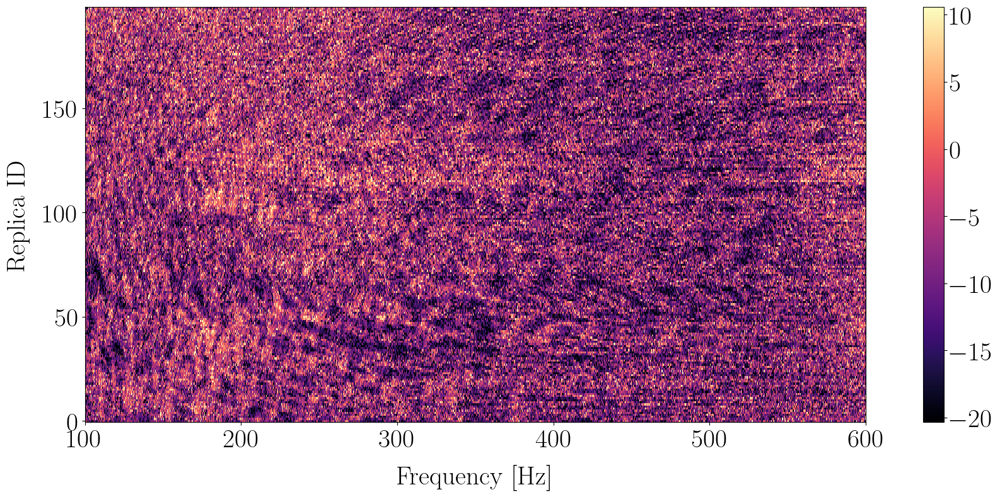

In [67]:
pi2_tilde = 20 * np.log10(np.abs(pi_tilde))

vmin = np.percentile(pi2_tilde, 5)
vmax = np.percentile(pi2_tilde, 95)

plt.figure()
im = plt.pcolormesh(
    f_fft,
    rep_id,
    pi2_tilde,
    cmap="magma",
    vmin=vmin,
    vmax=vmax,
    # vmin=np.percentile(pi2, 0.001),
    # vmax=np.percentile(pi2, 0.99999),
)
plt.xlim(100, 600)
# plt.ylim(50, 400)
plt.colorbar(im)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Replica ID")

Text(0, 0.5, 'Replica ID')

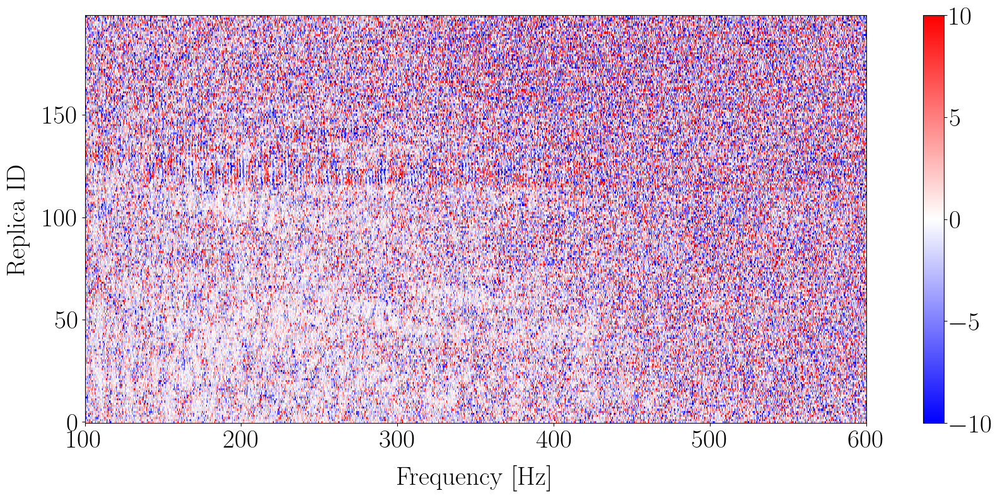

In [68]:
diff_pi = pi2_tilde - pi2_47
# diff_pi = 20 * np.log10(np.abs(pi_tilde) - np.abs(pi))

plt.figure()
im = plt.pcolormesh(
    f_fft,
    rep_id,
    diff_pi,
    cmap="bwr",
    vmin=-10,
    vmax=10,
)
plt.xlim(100, 600)
# plt.ylim(50, 400)
plt.colorbar(im)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Replica ID")

Différence notable entre les deux méthodes de calcul. La différence traduit le motif général observé. 